## ***ReLU Activation in a Pair of Neurons***

We believe it is less obvious how, with a barely nonlinear activation function, like the rectified
linear activation function, we can suddenly map nonlinear relationships and functions, so now
let’s cover that. 

Let’s start again with a single neuron. We’ll begin with both a weight of 0 and a
bias of 0:

## ***1 - Neuron***

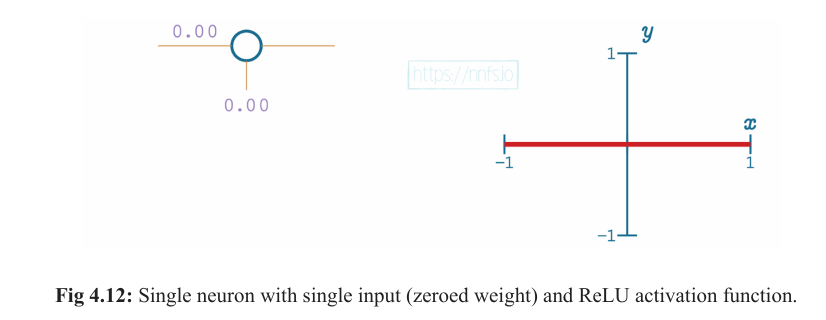

In this case, no matter what input we pass, the output of this neuron will always be a 0, because
the weight is 0, and there’s no bias. Let’s set the weight to be 1:

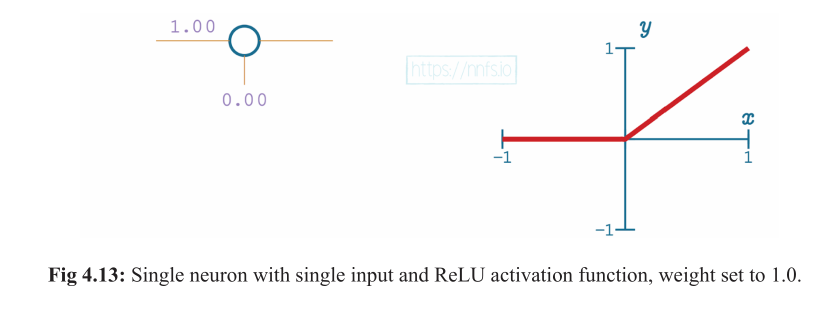

Now it looks just like the basic rectified linear function, no surprises yet! Now let’s set the bias to
0.50:

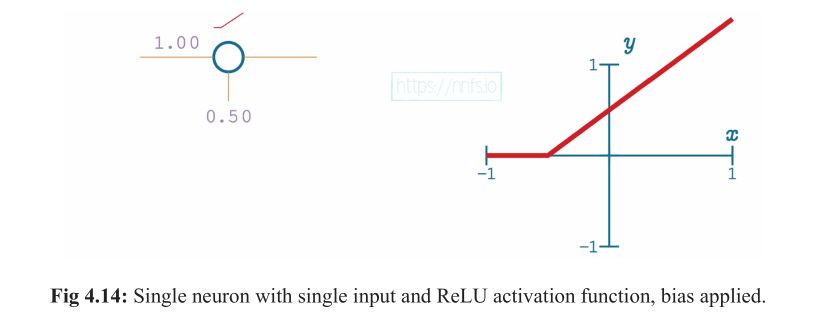

We can see that, in this case, with a single neuron, the bias offsets the overall function’s
activation point ​horizontally.​ By increasing bias, we’re making this neuron activate earlier. What
happens when we negate the weight to -1.0?

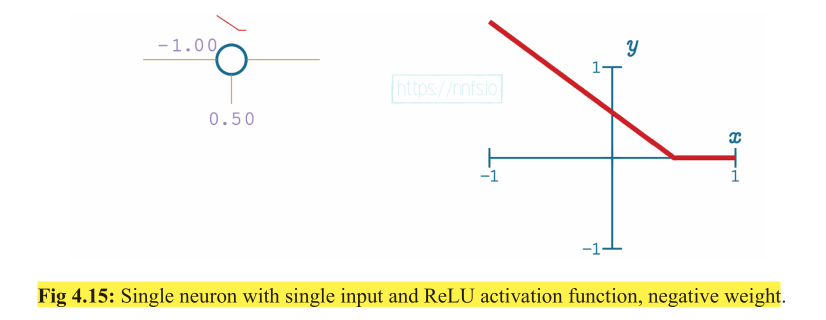

With a negative weight and this single neuron, the function has become a question of when this
neuron ​deactivates.​ 

Up to this point, you’ve seen how we can use the bias to offset the function
horizontally, and the weight to influence the slope of the activation. 

Moreover, we’re also able to
control whether the function is one for determining where the neuron activates or deactivates.

## ***2 - Neurons***

What happens when we have, rather than just the one neuron, a pair of neurons? For example,
let’s pretend that we have 2 hidden layers of 1 neuron each. 

Thinking back to the ​y=x​ activation
function, we unsurprisingly discovered that a linear activation function produced linear results no
matter what chain of neurons we made. 

Let’s see what happens with the rectified linear function
for the activation. We’ll begin with the last values for the 1st neuron and a weight of 1, with a
bias of 0, for the 2nd neuron:

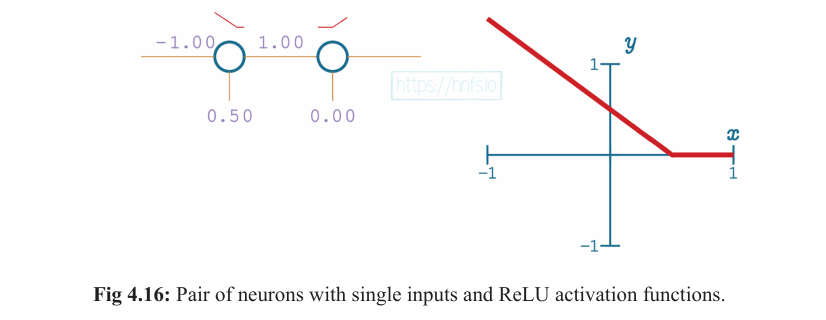

As we can see so far, there’s no change. This is because the 2nd neuron’s bias is doing no
offsetting, and the 2nd neuron’s weight is just multiplying output by 1, so there’s no change. 

Let’s
try to adjust the 2nd neuron’s bias now:

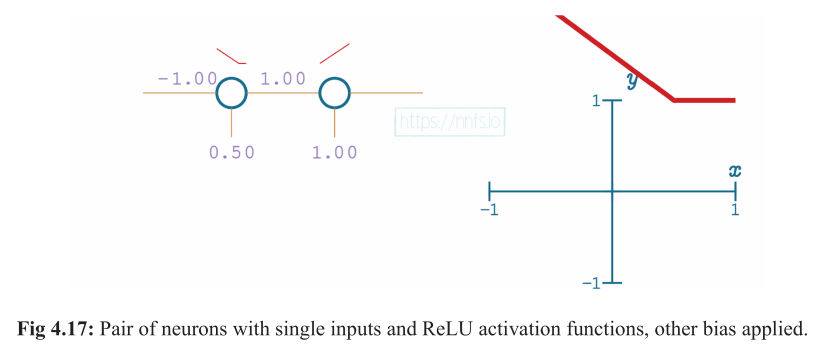

Now we see some fairly interesting behavior. The bias of the second neuron indeed shifted the
overall function, but, rather than shifting it ​horizontally,​ it shifted the function ​vertically.​ 

What
then might happen if we make that 2nd neuron’s weight -2 rather than 1?

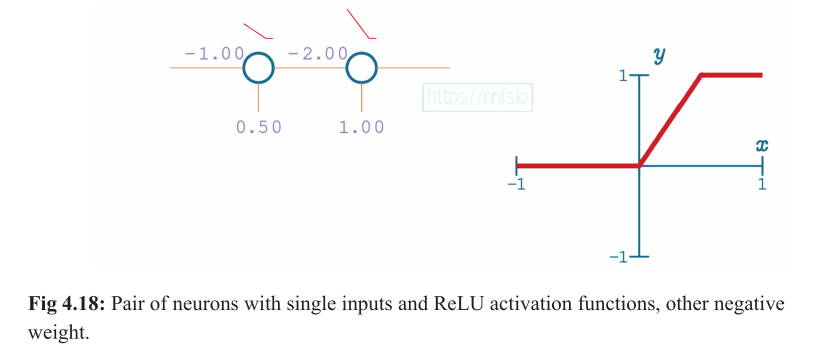

Something exciting has occurred! What we have here is a neuron that has both an activation and a
deactivation point. 

When ​both​ neurons are activated, when their “area of effect” comes into play,
they produce values in the range of the granular, variable, and output. 

If any neuron in the pair is
inactive, the pair will produce non-variable output:

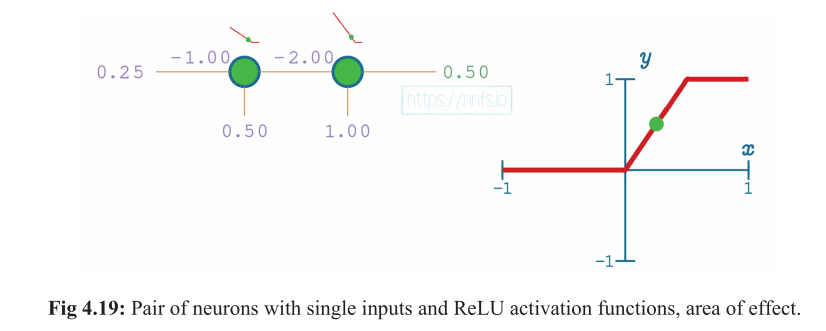

## ***ReLU Activation in the Hidden Layers***

- Let’s now take this concept and use it to fit to the ***sine wave*** function using 2 hidden layers of 8 neurons each, and we can ***hand-tune*** the values to fit the curve. 

- We’ll do this by working with 1 pair of neurons at a time, which means 1 neuron from each layer individually. 

- For simplicity, we are also going to assume that the layers are ***not densely connected***, and each neuron from the first hidden layer connects to only one neuron from the second hidden layer. 

- That’s usually not the case with the real models, but we want this simplification for the purpose of this demo.

- Additionally, this example model takes a single value as an input, the input to the ***sine function***, and outputs a ***single value*** like the sine function. 

- The ***output layer*** uses the ***Linear activation function***, and the ***hidden layers*** will use the ***rectified linear activation function***.

- To start, we’ll set all weights to 0 and work with the first pair of neurons:

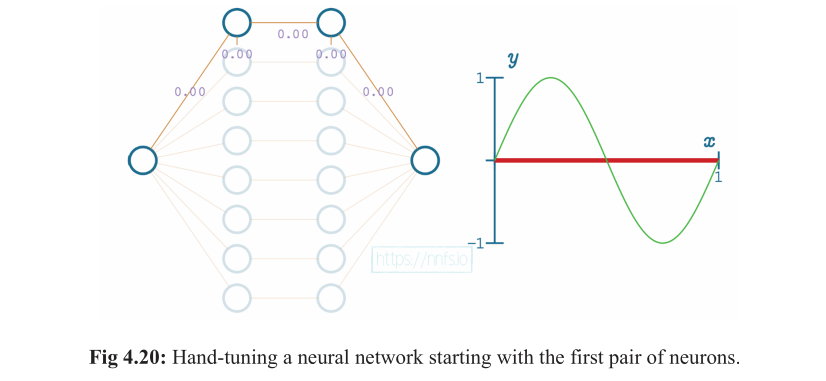

Next, we can set the weight for the hidden layer neurons and the output neuron to 1, and we can
see how this impacts the output:

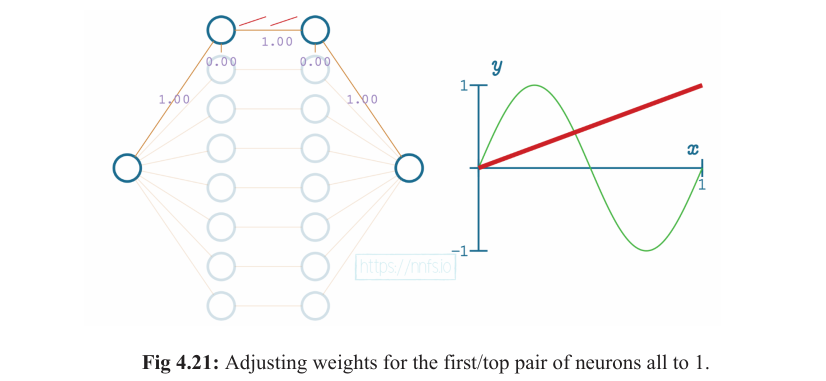

In this case, we can see that the slope of the overall function is impacted. We can further increase
this slope by adjusting the weight for the first neuron of the first layer to 6.0:

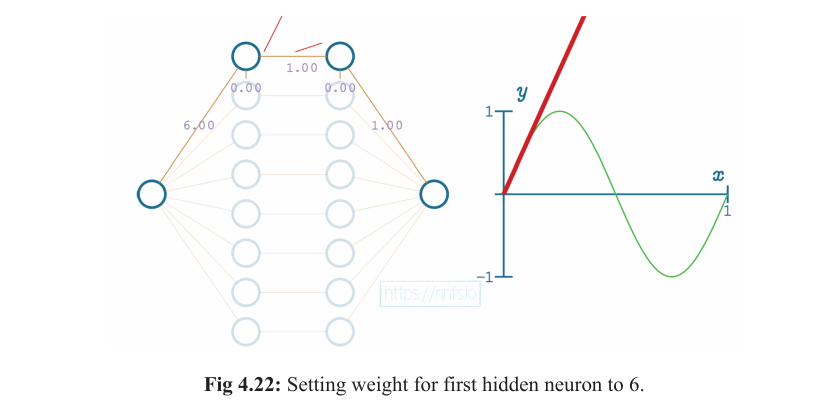

We can now see, for example, that the initial slope of this function is what we’d like, but we have
a problem. 

Currently, this function never ends because this neuron pair never ​deactivates​. We can
visually see where we’d like the deactivation to occur. 

It’s where the red fitment line (our current
neural network’s output) diverges initially from the green sine wave. 

So now, while we have the
correct slope, we need to set this spot as our deactivation point. 

To do that, we start by increasing the bias for the 2nd neuron of the hidden layer pair to 0.70. Recall that this offsets the overall
function ​vertically​:

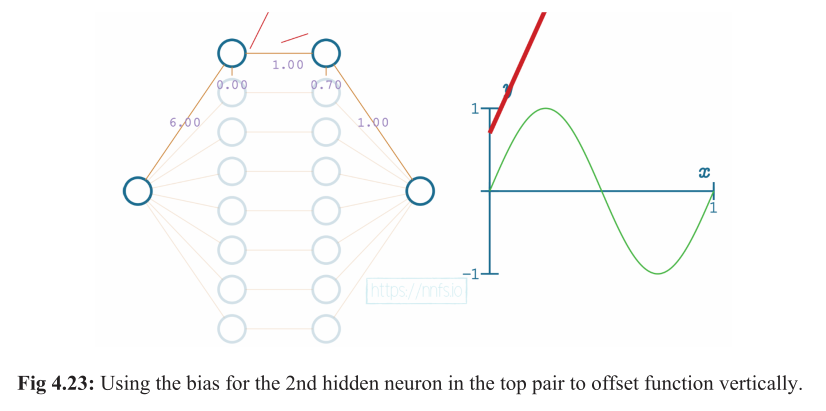

Now we can set the weight for the 2nd neuron to -1, causing a deactivation point to occur, at least
horizontally, where we want it:

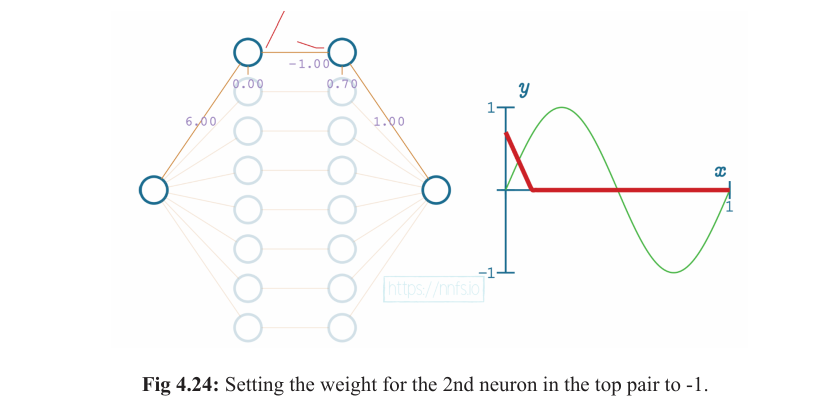

Now we’d like to flip this slope back. How might we flip the output of these two neurons? 

It seems like we can take the weight of the connection to the output neuron, which is currently a 1.0,
and just flip it to a -1, and that flips the function:

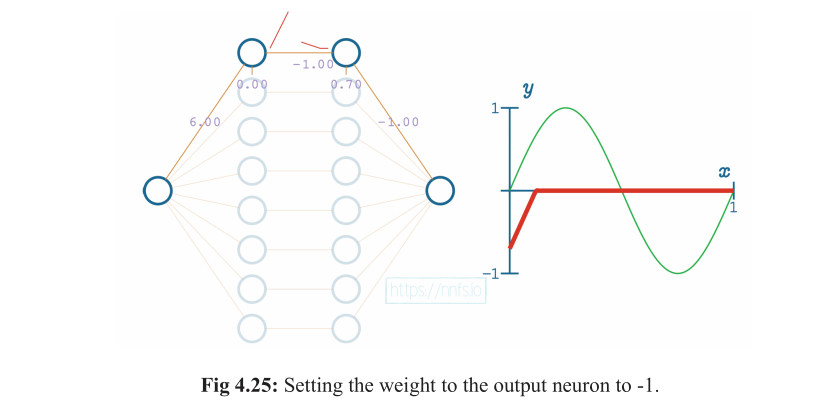

We’re certainly getting closer to making this first section fit how we want. Now, all we need to
do is offset this up a bit. 

For this hand-optimized example, we’re going to use the first 7 pairs of
neurons in the hidden layers to create the sine wave’s shape, then the bottom pair to offset
everything vertically. 

If we set the bias of the 2nd neuron in the bottom pair to 1.0 and the
weight to the output neuron as 0.7, we can vertically shift the line like so:

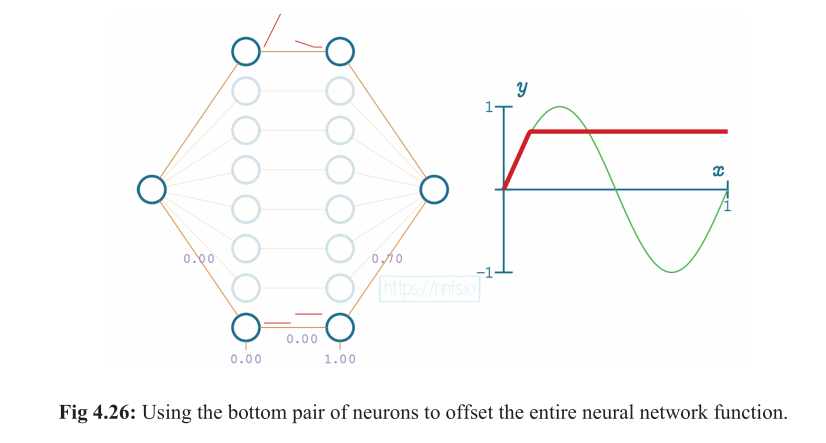

At this point, we have completed the first section with an “area of effect” being the first upward
section of the sine wave. 

We can start on the next section that we wish to do. We can start by
setting all weights for this 2nd pair of neurons to 1, including the output neuron:

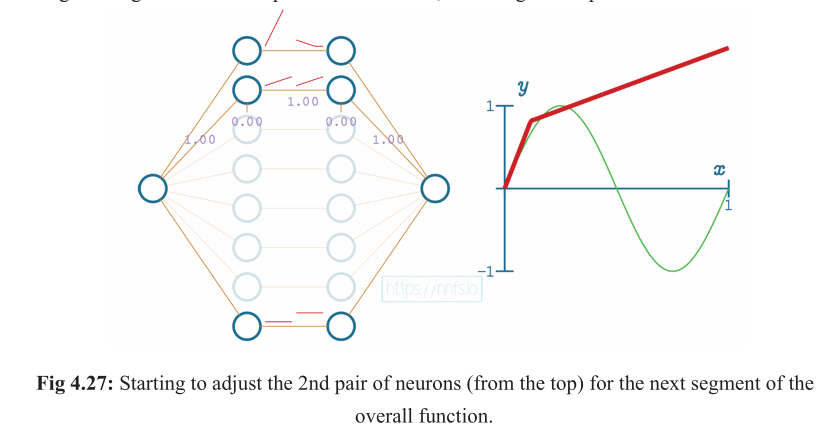

At this point, this 2nd pair of neurons’ activation is beginning too soon, which is impacting the
“area of effect” of the top pair that we already aligned. 

To fix this, we want this second pair to
start influencing the output where the first pair deactivates, so we want to adjust the function
horizontally. 

As you can recall from earlier, we adjust the first neuron’s bias in this neuron pair to
achieve this. 

Also, to modify the slope, we’ll set the weight coming into that first neuron for the
2nd pair, setting it to 3.5. 

This is the same method we used to set the slope for the first section,
which is controlled by the top pair of neurons in the hidden layer. After these adjustments:

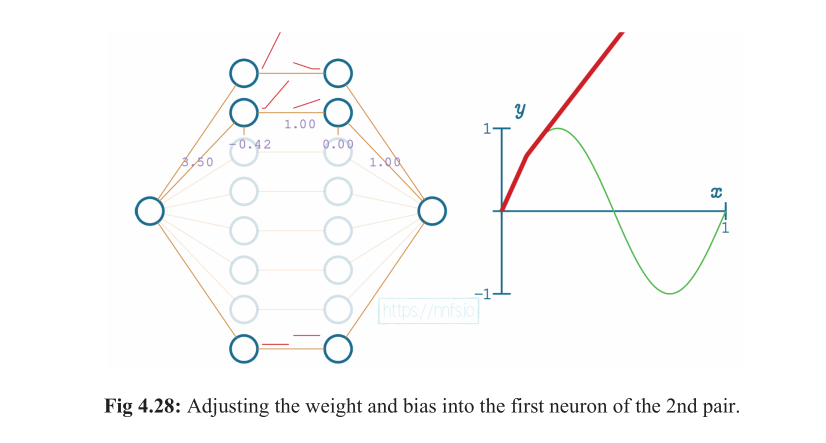

We will now use the same methodology as we did with the first pair to set the deactivation point.

We set the weight for the 2nd neuron in the hidden layer pair to -1 and the bias to 0.27.

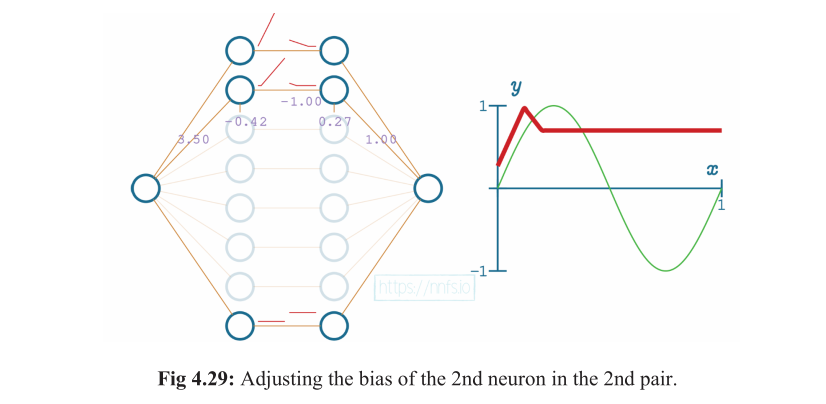

Then we can flip this section’s function, again the same way we did with the first one, by setting
the weight to the output neuron from 1.0 to -1.0:

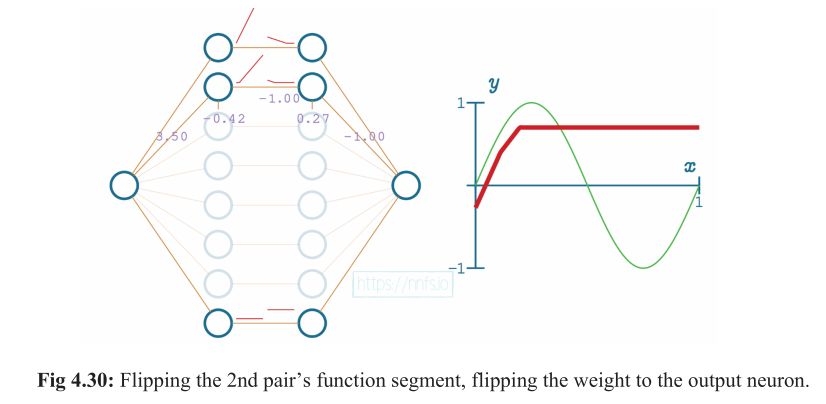

And again, just like the first pair, we will use the bottom pair to fix the vertical offset:

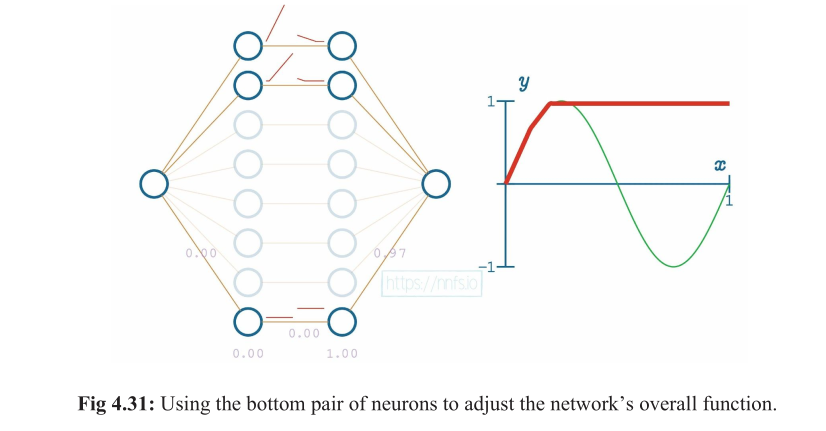

We then just continue with this methodology. 

We’ll leave it flat for the top section, which means
we will only begin the activation for the 3rd pair of hidden layer neurons when we wish for the slope to start going down:

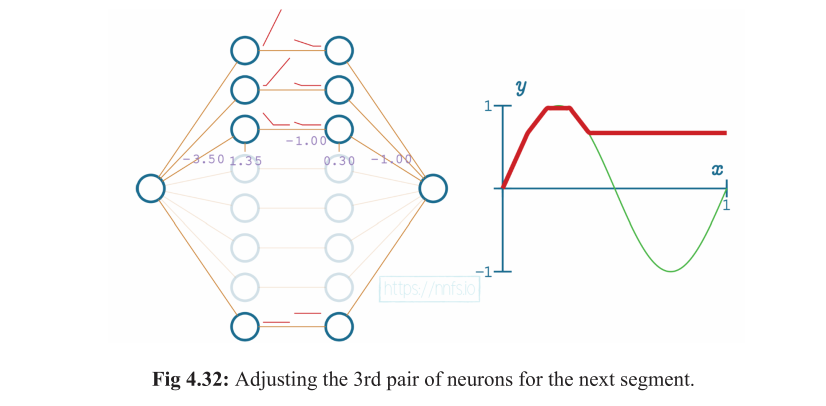

This process is simply repeated for each section, giving us a final result:

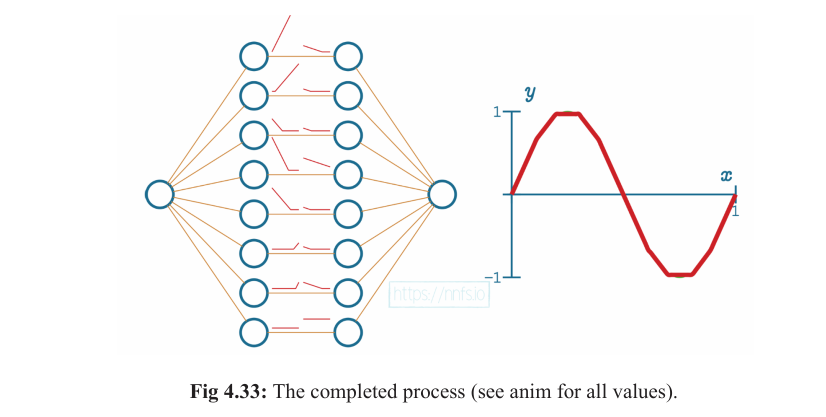

We can then begin to pass data through to see how these neuron’s areas of effect come into play
— only when both neurons are activated based on input:

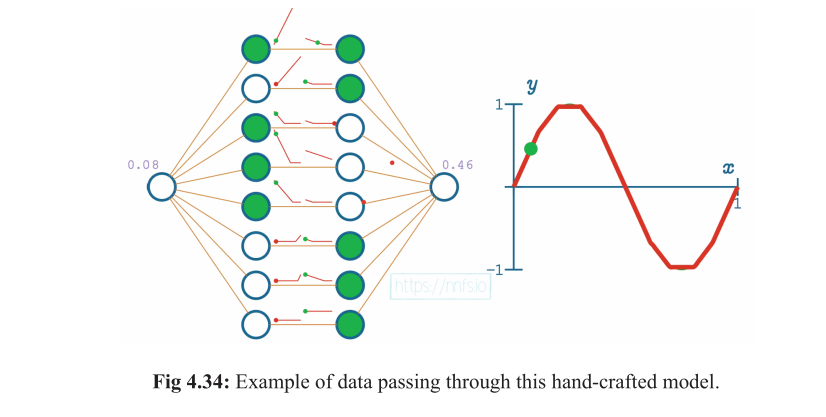

In this case, given an input of 0.08, we can see the only pairs activated are the top ones, as this is
their area of effect. 

Continuing with another example:

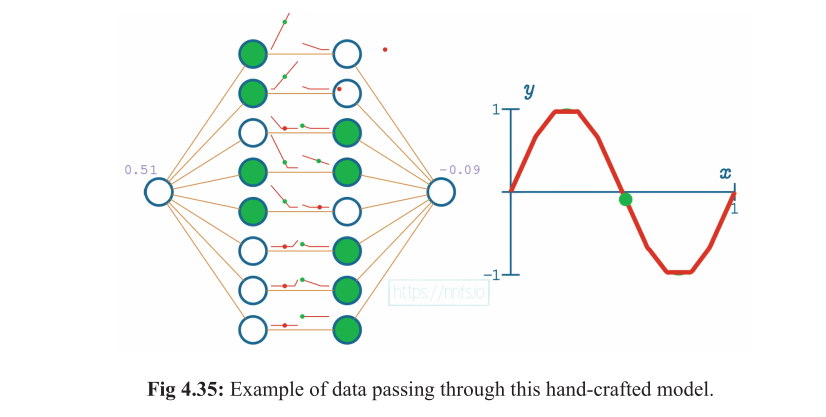

In this case, only the fourth pair of neurons is activated. 

As you can see, even without any of the
other weights, we’ve used some crude properties of a pair of neurons with rectified linear
activation functions to fit this sine wave pretty well. 

If we enable all of the weights now and allow
a mathematical optimizer to train, we can see even better fitment:

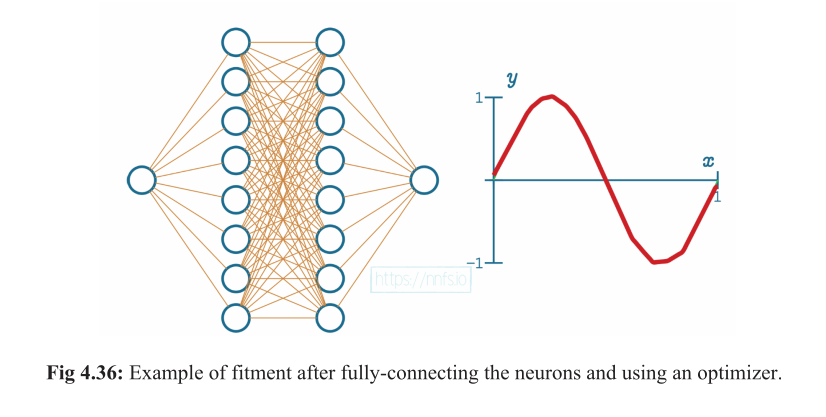

It should begin to make more sense to you now how more neurons can enable more unique areas
of effect, why we need two or more hidden layers, and why we need nonlinear activation
functions to map nonlinear problems. 

For further example, we can take the above example with 2
hidden layers of 8 neurons each, and instead use 64 neurons per hidden layer, seeing the even
further continued improvement:

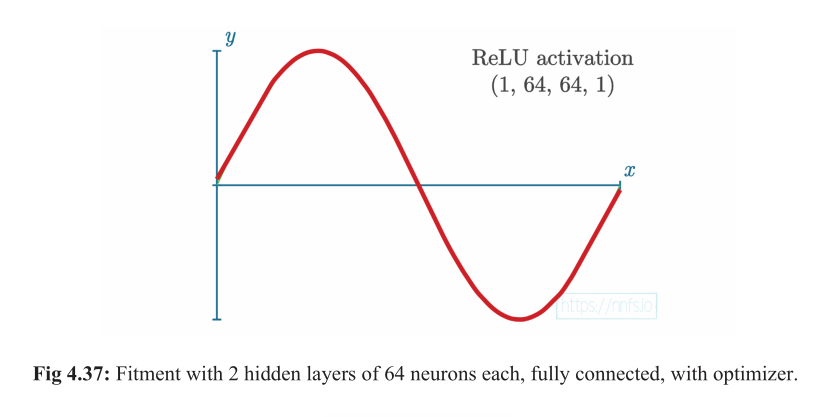

***Animation Video for ReLU***

- https://nnfs.io/mvp/

## ***ReLU Activation Function Code in Python***

Despite the fancy sounding name, the rectified linear activation function is straightforward to

code. Most closely to its definition:

In [4]:
# ReLU using if-else (verbose)
inputs = [0, 2, -1, 3.3, -2.7, 1.1, 2.2, -100]
output = []

for i in inputs:
    if i > 0:
        output.append(i)
    else:
        output.append(0)

print(output)
# Output: [0, 2, 0, 3.3, 0, 1.1, 2.2, 0]

[0, 2, 0, 3.3, 0, 1.1, 2.2, 0]


In [3]:
# ReLU using max(0, i) — Recommended
inputs = [0, 2, -1, 3.3, -2.7, 1.1, 2.2, -100]
output = []

for i in inputs:
    output.append(max(0, i))

print(output)
# Output: [0, 2, 0, 3.3, 0, 1.1, 2.2, 0]

[0, 2, 0, 3.3, 0, 1.1, 2.2, 0]


In [6]:
import numpy as np
from nnfs.datasets import spiral_data

# ReLU using np.maximum
inputs = [0, 2, -1, 3.3, -2.7, 1.1, 2.2, -100]
output = np.maximum(0, inputs)
print(output)
# [0.  2.  0.  3.3 0.  1.1  2.2  0. ]

[0.  2.  0.  3.3 0.  1.1 2.2 0. ]


This method compares each element of the input list (or an array) and returns an object of the
same shape filled with new values. 

We will use it in our new rectified linear activation class:

In [8]:
# ReLU Activation Class
class Activation_ReLU:
    def forward(self, inputs):
        self.output = np.maximum(0, inputs)


# Create dataset
X, y = spiral_data(samples=100, classes=3)

# Dense layer (simplified)
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
    
    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases


# Create dense layer: 2 input features → 3 neurons
dense1 = Layer_Dense(2, 3) 

# Create ReLU activation
activation1 = Activation_ReLU()

# Forward pass through dense layer
dense1.forward(X)

# Apply ReLU activation
activation1.forward(dense1.output)

# Result stored in:
print(activation1.output[:5])  # First 5 samples

[[0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [6.51213419e-05 0.00000000e+00 0.00000000e+00]
 [1.58030006e-04 0.00000000e+00 0.00000000e+00]
 [2.37089320e-04 0.00000000e+00 0.00000000e+00]
 [3.02284017e-04 0.00000000e+00 0.00000000e+00]]


As you can see, negative values have been ​clipped​ (modified to be zero). 

That’s all there is to the
rectified linear activation function used in the hidden layer. 

Let’s talk about the activation
function that we are going to use on the output of the last layer.